# CR3 — Model Design for FER2013

INSAT GL4 — Image Processing — Week 3 (13/04/2026)

**Group:** Rayen Chemlali, Mohamed Dhia Medini, Khalil Ghimaji, Mohamed Achref Hemissi

---

## Objectives
1. Justify the choice of Deep Learning over classical ML
2. Design and compare three architectures: Baseline CNN, ResNet-50, EfficientNet-B0
3. Correct the normalization statistics (must be computed **after** CLAHE, not on raw images)
4. Build the complete training pipeline with data augmentation
5. Describe the class imbalance strategy (preview for Week 4)

---
## Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import yaml
from tqdm import tqdm

import torch
import torch.nn as nn
from torchvision import transforms as T
from torch.utils.data import DataLoader, WeightedRandomSampler

ROOT = Path("..")
sys.path.insert(0, str(ROOT / "src"))

from dataset import FERDataset
from transforms import GaussianDenoise, CLAHE, AddGaussianNoise
from model import BaselineCNN, TransferModel, build_model

with open(ROOT / "configs" / "config.yaml") as f:
    config = yaml.safe_load(f)

DATA_ROOT   = ROOT / config["data"]["root"]
CLASS_NAMES = config["data"]["class_names"]
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   12,
    "axes.titleweight": "bold",
})

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print("Setup OK")

Device  : cuda
PyTorch : 2.11.0+cu130
Setup OK


---
## 1. Approach: Deep Learning vs Classical ML

| Criterion | Classical ML (SVM, RF + HOG/LBP) | Deep Learning (CNN) |
| --- | --- | --- |
| Feature extraction | Manual (HOG, LBP, Gabor) | Learned automatically |
| FER2013 accuracy | ~45–55% | ~65–72% |
| Handles lighting variation | Poorly (fixed filters) | Yes (CLAHE + learned features) |
| Class imbalance handling | Hard to tune | Class weights + sampler |
| Scalable to more data | No | Yes |

**Decision: Deep Learning.**  
FER2013 at 48×48 is small enough to train a custom CNN from scratch, and large enough (28 K training images) to benefit from learned representations.  
Three architectures will be evaluated:
- **Baseline CNN** — custom lightweight CNN, ~390 K parameters, trained from scratch
- **ResNet-50** — transfer learning from ImageNet, ~23 M parameters, only head retrained initially
- **EfficientNet-B0** — more efficient transfer learning, ~4 M parameters, good accuracy/size tradeoff

---
## 2. Model Architectures

In [2]:
def count_params(model: nn.Module):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

# Instantiate all three (pretrained=False to avoid downloading weights here)
dummy = torch.zeros(1, 1, 48, 48)

models_cfg = [
    ("Baseline CNN",    "baseline_cnn"),
    ("ResNet-50",       "resnet50"),
    ("EfficientNet-B0", "efficientnet_b0"),
]

print(f"{'Model':<20}  {'Output shape':<15}  {'Total params':>13}  {'Trainable':>13}")
print("-" * 68)

results = {}
for label, name in models_cfg:
    cfg = {**config, "model": {**config["model"], "name": name, "pretrained": False}}
    m   = build_model(cfg).eval()
    with torch.no_grad():
        out = m(dummy)
    total, trainable = count_params(m)
    results[label] = {"total": total, "trainable": trainable}
    print(f"{label:<20}  {str(tuple(out.shape)):<15}  {total:>13,}  {trainable:>13,}")

Model                 Output shape      Total params      Trainable
--------------------------------------------------------------------
Baseline CNN          (1, 7)                 390,119        390,119
ResNet-50             (1, 7)              23,516,103     23,516,103
EfficientNet-B0       (1, 7)               4,015,939      4,015,939


/tmp/ipykernel_3715/1882931783.py:30: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(


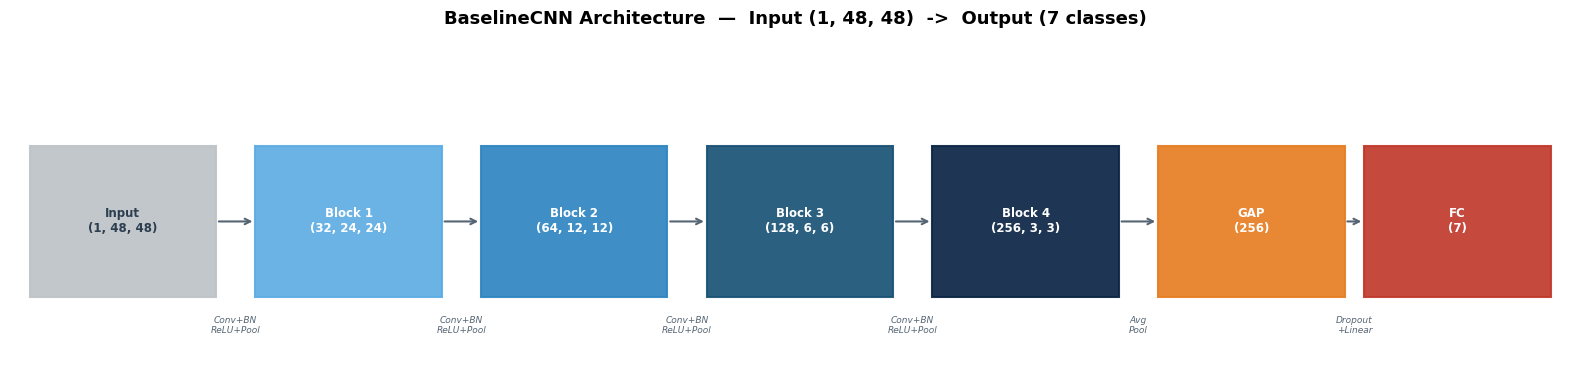

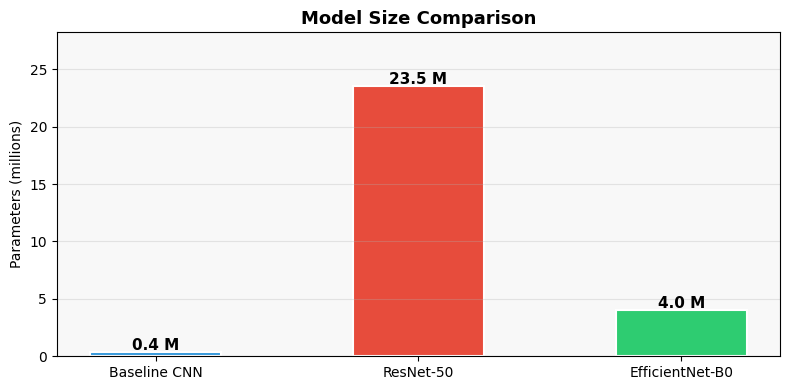

In [3]:
# ── BaselineCNN architecture diagram ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 16)
ax.set_ylim(0, 4)
ax.axis("off")

layers = [
    {"label": "Input\n(1, 48, 48)",    "color": "#bdc3c7", "x": 0.2},
    {"label": "Block 1\n(32, 24, 24)",  "color": "#5dade2", "x": 2.5},
    {"label": "Block 2\n(64, 12, 12)",  "color": "#2e86c1", "x": 4.8},
    {"label": "Block 3\n(128, 6, 6)",   "color": "#1a5276", "x": 7.1},
    {"label": "Block 4\n(256, 3, 3)",   "color": "#0b2545", "x": 9.4},
    {"label": "GAP\n(256)",             "color": "#e67e22", "x": 11.7},
    {"label": "FC\n(7)",                "color": "#c0392b", "x": 13.8},
]

ops = [
    "Conv+BN\nReLU+Pool",
    "Conv+BN\nReLU+Pool",
    "Conv+BN\nReLU+Pool",
    "Conv+BN\nReLU+Pool",
    "Avg\nPool",
    "Dropout\n+Linear",
]

BOX_W, BOX_H, BOX_Y = 1.9, 1.8, 1.0

for layer in layers:
    fc = "white" if layer["color"] not in ("#bdc3c7",) else "#2c3e50"
    ax.add_patch(plt.Rectangle(
        (layer["x"], BOX_Y), BOX_W, BOX_H,
        color=layer["color"], alpha=0.92, zorder=2,
        linewidth=1.5, edgecolor="white",
    ))
    ax.text(
        layer["x"] + BOX_W / 2, BOX_Y + BOX_H / 2,
        layer["label"], ha="center", va="center",
        fontsize=8.5, fontweight="bold", color=fc, zorder=3,
    )

for i, (layer, op) in enumerate(zip(layers[:-1], ops)):
    x_start = layer["x"] + BOX_W
    x_end   = layers[i + 1]["x"]
    x_mid   = (x_start + x_end) / 2
    ax.annotate(
        "", xy=(x_end, BOX_Y + BOX_H / 2),
        xytext=(x_start, BOX_Y + BOX_H / 2),
        arrowprops=dict(arrowstyle="->", color="#566573", lw=1.5),
    )
    ax.text(x_mid, BOX_Y - 0.35, op, ha="center", va="center",
            fontsize=6.5, color="#566573", style="italic")

ax.set_title(
    "BaselineCNN Architecture  —  Input (1, 48, 48)  ->  Output (7 classes)",
    fontsize=13, fontweight="bold", pad=16,
)
plt.tight_layout()
plt.savefig(ROOT / "results" / "cr3_architecture.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Parameter bar chart ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
names  = list(results.keys())
totals = [results[n]["total"] / 1e6 for n in names]
colors = ["#3498db", "#e74c3c", "#2ecc71"]
bars   = ax.bar(names, totals, color=colors, edgecolor="white", linewidth=1.5, width=0.5)
for bar, val in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{val:.1f} M", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Parameters (millions)")
ax.set_title("Model Size Comparison", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(totals) * 1.2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "results" / "cr3_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Corrected Normalization Statistics

**Problem identified in Week 2:** the normalization statistics (mean=0.507, std=0.255) were computed on **raw images**.  
In the actual training pipeline, CLAHE is applied **before** normalization, which changes the pixel distribution.  
Using raw-image statistics on CLAHE-enhanced inputs would produce a shifted distribution — not zero mean / unit variance.

**Fix:** recompute mean and std on the train set **after** the full preprocessing chain (denoise → CLAHE → /255).

In [4]:
ds_train = FERDataset(str(DATA_ROOT), split="train")

_denoise = GaussianDenoise()
_clahe   = CLAHE()

pixel_vals = []
for img_np in tqdm(ds_train.images, desc="Computing stats after CLAHE"):
    img = Image.fromarray(img_np, mode="L")
    img = _denoise(img)
    img = _clahe(img)
    pixel_vals.append(np.array(img).flatten() / 255.0)

all_pixels = np.concatenate(pixel_vals)
MEAN_CLAHE = round(float(all_pixels.mean()), 4)
STD_CLAHE  = round(float(all_pixels.std()),  4)

print(f"Raw images  : mean=0.5077  std=0.2551  (Week 2 values — incorrect for training)")
print(f"After CLAHE : mean={MEAN_CLAHE:.4f}  std={STD_CLAHE:.4f}  (corrected — use these)")

# Update config.yaml with corrected values
config["preprocessing"] = {"mean": MEAN_CLAHE, "std": STD_CLAHE}
with open(ROOT / "configs" / "config.yaml", "w") as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False, allow_unicode=True)
print("\nconfig.yaml updated with corrected normalization stats.")

Computing stats after CLAHE: 100%|███████████████████████████████████████████████████████████████| 28709/28709 [00:02<00:00, 9882.77it/s]


Raw images  : mean=0.5077  std=0.2551  (Week 2 values — incorrect for training)
After CLAHE : mean=0.5630  std=0.2627  (corrected — use these)

config.yaml updated with corrected normalization stats.


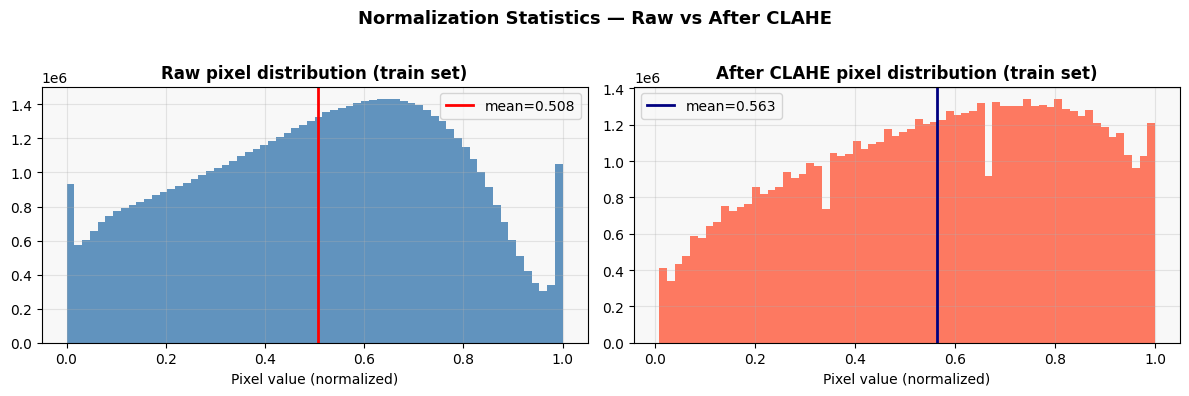

In [5]:
# Visual comparison: raw vs CLAHE pixel distribution
raw_pixels = np.concatenate([img.flatten() / 255.0 for img in ds_train.images])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(raw_pixels, bins=64, color="steelblue", alpha=0.85)
axes[0].axvline(raw_pixels.mean(), color="red", linewidth=2,
                label=f"mean={raw_pixels.mean():.3f}")
axes[0].set_title("Raw pixel distribution (train set)")
axes[0].set_xlabel("Pixel value (normalized)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(all_pixels, bins=64, color="tomato", alpha=0.85)
axes[1].axvline(all_pixels.mean(), color="navy", linewidth=2,
                label=f"mean={MEAN_CLAHE:.3f}")
axes[1].set_title("After CLAHE pixel distribution (train set)")
axes[1].set_xlabel("Pixel value (normalized)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Normalization Statistics — Raw vs After CLAHE",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "results" / "cr3_normalization.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Transform Pipelines

Two distinct pipelines — **training** applies data augmentation, **validation/test** does not.

```
TRAINING                          VALIDATION / TEST
────────────────────────────      ────────────────────────────
GaussianDenoise                   GaussianDenoise
CLAHE                             CLAHE
RandomHorizontalFlip(p=0.5)       ToTensor
RandomRotation(±10°)              Normalize(mean, std)
ColorJitter(bright, contrast)
RandomResizedCrop(48, 0.9-1.1)
ToTensor
Normalize(mean, std)
```

All augmentation parameters come from `configs/config.yaml → augmentation`.

In [6]:
aug = config["augmentation"]

train_transform = T.Compose([
    GaussianDenoise(),
    CLAHE(),
    T.RandomHorizontalFlip(p=aug["horizontal_flip"]),
    T.RandomRotation(degrees=aug["rotation_degrees"]),
    T.ColorJitter(
        brightness=aug["brightness"],
        contrast=aug["contrast"],
    ),
    T.RandomResizedCrop(
        config["data"]["image_size"],
        scale=aug["zoom_scale"],
        ratio=(1.0, 1.0),
    ),
    T.ToTensor(),
    T.Normalize(mean=(MEAN_CLAHE,), std=(STD_CLAHE,)),
])

val_transform = T.Compose([
    GaussianDenoise(),
    CLAHE(),
    T.ToTensor(),
    T.Normalize(mean=(MEAN_CLAHE,), std=(STD_CLAHE,)),
])

print("Train transform:")
print(train_transform)
print()
print("Val/Test transform:")
print(val_transform)

Train transform:
Compose(
    GaussianDenoise(kernel=(3,3), sigma=0.8)
    CLAHE(clipLimit=2.0, tileGridSize=(4,4))
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.8, 1.2), saturation=None, hue=None)
    RandomResizedCrop(size=(48, 48), scale=(0.9, 1.1), ratio=(1.0, 1.0), interpolation=bilinear, antialias=True)
    ToTensor()
    Normalize(mean=(0.563,), std=(0.2627,))
)

Val/Test transform:
Compose(
    GaussianDenoise(kernel=(3,3), sigma=0.8)
    CLAHE(clipLimit=2.0, tileGridSize=(4,4))
    ToTensor()
    Normalize(mean=(0.563,), std=(0.2627,))
)


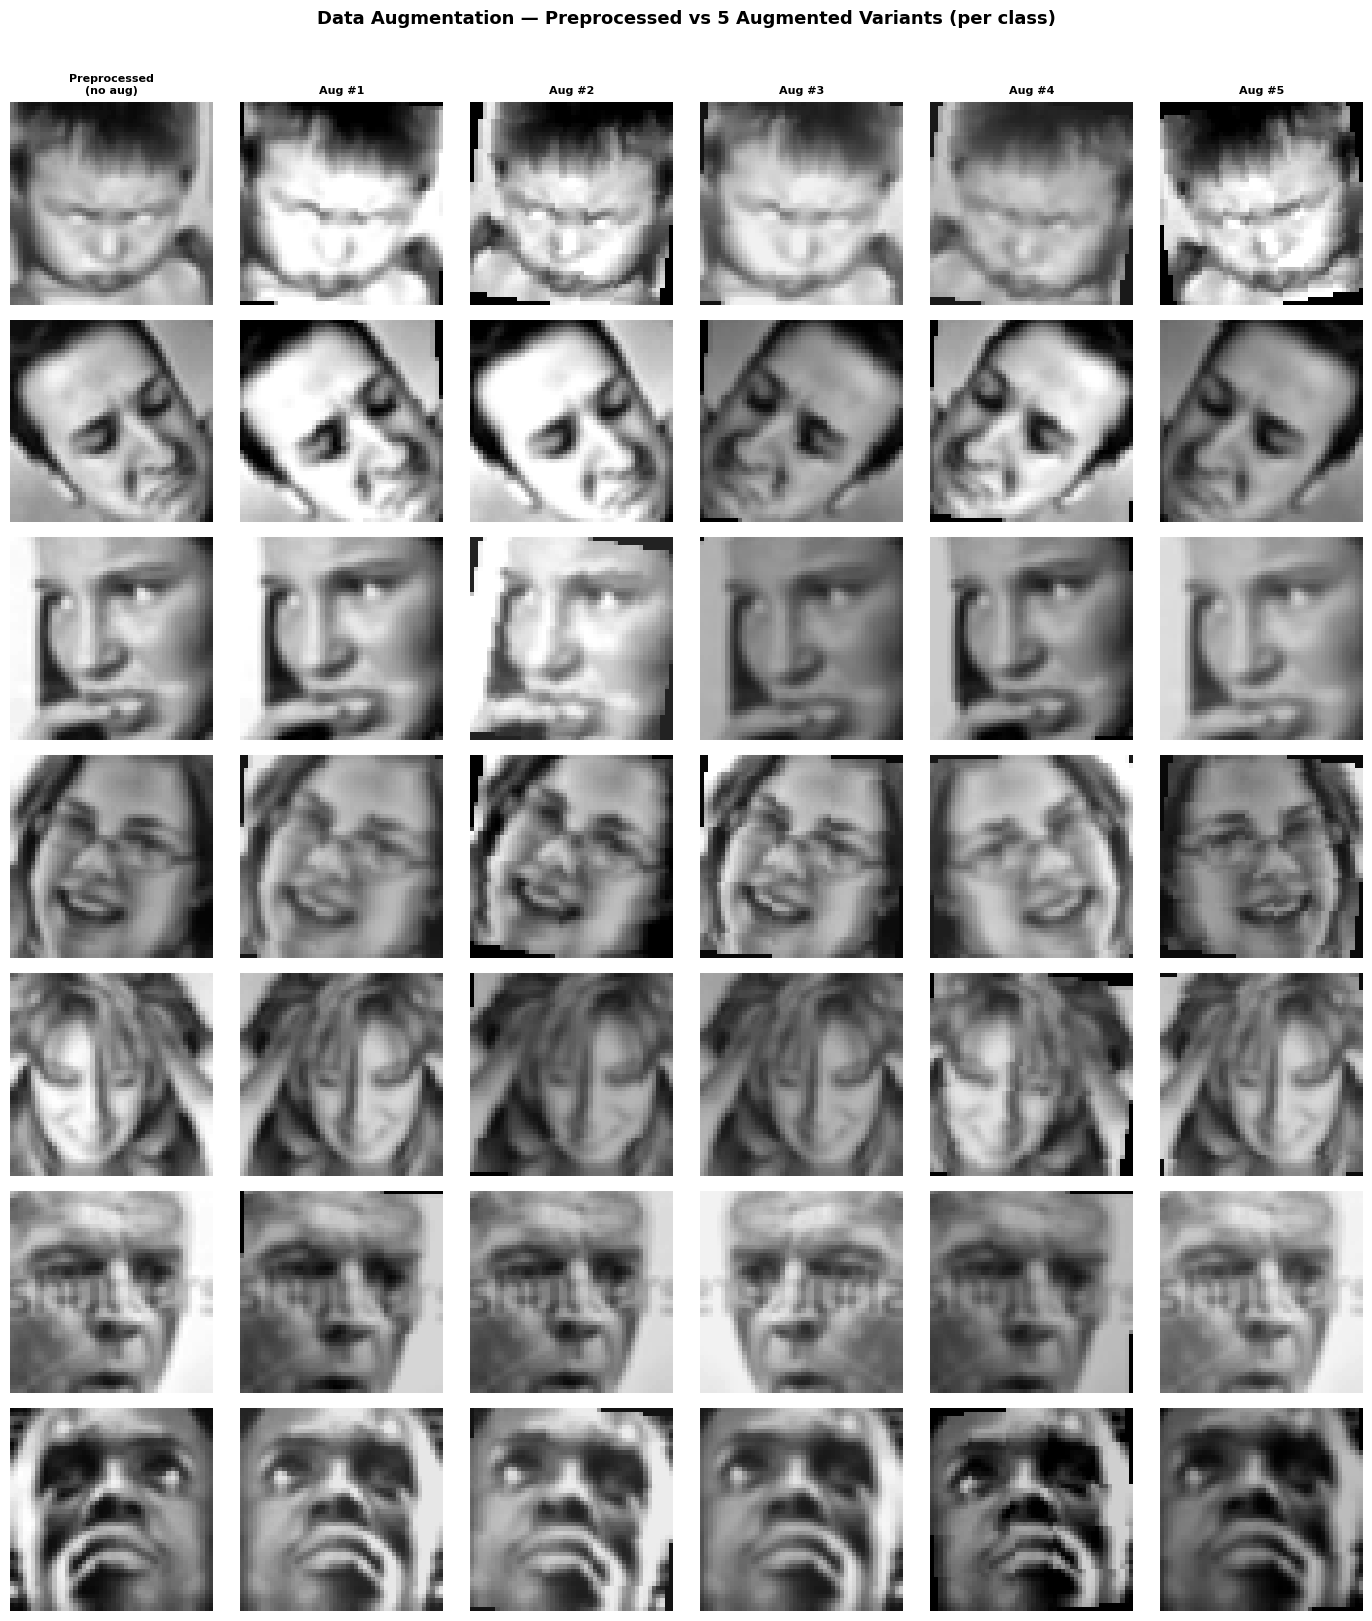

In [7]:
# Load one sample per class (raw PIL images for display)
ds_raw = FERDataset(str(DATA_ROOT), split="train")
class_samples = {}
for img_np, label in zip(ds_raw.images, ds_raw.labels):
    if label not in class_samples:
        class_samples[label] = Image.fromarray(img_np, mode="L")
    if len(class_samples) == 7:
        break

# Augmentation-only transform (no ToTensor/Normalize — for visual display)
aug_display = T.Compose([
    GaussianDenoise(),
    CLAHE(),
    T.RandomHorizontalFlip(p=aug["horizontal_flip"]),
    T.RandomRotation(degrees=aug["rotation_degrees"]),
    T.ColorJitter(brightness=aug["brightness"], contrast=aug["contrast"]),
    T.RandomResizedCrop(
        config["data"]["image_size"],
        scale=aug["zoom_scale"],
        ratio=(1.0, 1.0),
    ),
])
clahe_only = T.Compose([GaussianDenoise(), CLAHE()])

N_AUG = 5
fig, axes = plt.subplots(7, N_AUG + 1, figsize=(14, 16))

for row, class_idx in enumerate(range(7)):
    img = class_samples[class_idx]

    # Column 0: preprocessed (no augmentation)
    preprocessed = clahe_only(img)
    axes[row, 0].imshow(np.array(preprocessed), cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_ylabel(CLASS_NAMES[class_idx], fontsize=9, rotation=0,
                             labelpad=55, va="center")
    if row == 0:
        axes[row, 0].set_title("Preprocessed\n(no aug)", fontsize=8)
    axes[row, 0].axis("off")

    # Columns 1-N_AUG: augmented variants
    for col in range(1, N_AUG + 1):
        aug_img = aug_display(img)
        axes[row, col].imshow(np.array(aug_img), cmap="gray", vmin=0, vmax=255)
        if row == 0:
            axes[row, col].set_title(f"Aug #{col}", fontsize=8)
        axes[row, col].axis("off")

plt.suptitle(
    "Data Augmentation — Preprocessed vs 5 Augmented Variants (per class)",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(ROOT / "results" / "cr3_augmentation.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 5. DataLoader Setup & Class Imbalance Strategy

**Strategy: `WeightedRandomSampler` only — unweighted loss.**

Using both sampler + weighted loss double-corrects for the imbalance:

| Mechanism | Disgust gradient multiplier |
| --- | --- |
| Sampler alone | ×2.3 (16/7 — appears more per batch) |
| Weighted loss alone | ×9.4 |
| Both together | ×2.3 × 9.4 ≈ **×21 — over-correction** |

Using both would make the model over-specialise on Disgust and hurt accuracy on majority classes.

**Correct setup:** sampler balances the batches → unweighted `CrossEntropyLoss` treats every sample in that balanced batch equally.

**Important:** only the **training** loader uses the sampler.
The **validation and test** loaders use the natural distribution so metrics reflect real-world performance.

In [ ]:
# Build datasets
train_ds = FERDataset(str(DATA_ROOT), split="train", transform=train_transform)
val_ds   = FERDataset(str(DATA_ROOT), split="val",   transform=val_transform)

# Class weights — shown for information only, NOT passed to the loss
class_weights = train_ds.get_class_weights()
print("Class weights (for reference — shows imbalance severity):")
for name, w in zip(CLASS_NAMES, class_weights):
    bar = "█" * int(w * 4)
    print(f"  {name:<10}: {w:.3f}  {bar}")

# WeightedRandomSampler — the only imbalance correction mechanism used
sample_weights = [class_weights[label] for label in train_ds.labels]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

BATCH_SIZE = config["training"]["batch_size"]

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)

# Unweighted loss — correct because batches are already balanced by the sampler
criterion = nn.CrossEntropyLoss()
print(f"\nLoss : {criterion}  (unweighted — sampler already balances batches)")

print(f"\nTrain loader : {len(train_loader)} batches x {BATCH_SIZE} = {len(train_ds)} samples")
print(f"Val loader   : {len(val_loader)} batches x {BATCH_SIZE} = {len(val_ds)} samples")

# Inspect one batch
batch_imgs, batch_labels = next(iter(train_loader))
print(f"\nBatch image shape : {tuple(batch_imgs.shape)}   (B, C, H, W)")
print(f"Batch label shape : {tuple(batch_labels.shape)}")
print(f"Pixel range       : [{batch_imgs.min():.3f}, {batch_imgs.max():.3f}]")

In [ ]:
# Verify sampler effect: count class occurrences in 50 training batches
from collections import Counter

label_counts = Counter()
for i, (_, labels) in enumerate(train_loader):
    label_counts.update(labels.tolist())
    if i >= 49:
        break

total_seen = sum(label_counts.values())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Original distribution
orig_dist = train_ds.get_distribution()
orig_vals = [orig_dist[n] for n in CLASS_NAMES]
ax1.bar(CLASS_NAMES, orig_vals, color="steelblue", edgecolor="white")
ax1.set_title("Original class distribution (train set)")
ax1.set_ylabel("Sample count")
ax1.tick_params(axis="x", rotation=20)
ax1.grid(axis="y", alpha=0.3)

# Sampled distribution (50 batches)
sampled_vals = [label_counts[i] for i in range(7)]
ax2.bar(CLASS_NAMES, sampled_vals, color="#e74c3c", edgecolor="white")
ax2.set_title("After WeightedRandomSampler (50 batches)")
ax2.set_ylabel("Sample count")
ax2.tick_params(axis="x", rotation=20)
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Class Imbalance — Before vs After Sampling",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "results" / "cr3_sampling.png", dpi=150, bbox_inches="tight")
plt.show()

print("Sampled class frequencies (50 batches):")
for i, name in enumerate(CLASS_NAMES):
    pct = 100 * label_counts[i] / total_seen
    print(f"  {name:<10}: {label_counts[i]:4d}  ({pct:.1f}%)")

---
## 6. Global Pipeline

```
FER2013 dataset (35,887 images, 7 classes)
          │
          ▼
  FERDataset  (src/dataset.py)
  ├── Auto-detect CSV or folder format
  ├── train split  : 28,709 images
  └── val/test split:  7,178 images
          │
          ├─── TRAINING path ───────────────────────────┐
          │    GaussianDenoise → CLAHE                  │
          │    RandomHorizontalFlip (p=0.5)             │
          │    RandomRotation (±10°, fill=128)          │
          │    ColorJitter (bright=0.3, contrast=0.2)   │
          │    RandomResizedCrop (48, scale=0.9-1.1)    │
          │    ToTensor → Normalize(0.563, 0.263)       │
          │    WeightedRandomSampler                    │
          │                                             │
          └─── VAL/TEST path ──────────────────────────►┤
               GaussianDenoise → CLAHE                  │
               ToTensor → Normalize(0.563, 0.263)       │
                                                        ▼
                                              DataLoader (batch=64)
                                                        │
                                                        ▼
                                       Model  (B, 1, 48, 48) → (B, 7)
                                       ├── Baseline CNN   (~390 K params)
                                       ├── ResNet-50       (~23 M params)
                                       └── EfficientNet-B0  (~4 M params)
                                                        │
                                                        ▼
                                         CrossEntropyLoss (unweighted)
                                         Sampler already balanced batches
                                                        │
                                                        ▼
                                      Adam (lr=0.001, wd=0.0001)
                                      ReduceLROnPlateau / CosineAnnealing
                                      Early stopping (patience=10)
                                                        │
                                                        ▼
                                  Evaluation: accuracy, confusion matrix,
                                              per-class F1 score
```

In [ ]:
print("=" * 60)
print("CR3 — MODEL DESIGN SUMMARY")
print("=" * 60)

print("\nAPPROACH")
print("  Deep Learning (CNN) — chosen over classical ML")
print("  Best FER2013 published results: ~70% with CNNs")
print("  Classical ML ceiling: ~50% with HOG+SVM")

print("\nARCHITECTURES")
for label, name in models_cfg:
    t = results[label]["total"]
    print(f"  {label:<20}: {t:>10,} params")

print("\nNORMALIZATION (corrected — after CLAHE)")
print(f"  Mean : {MEAN_CLAHE}  (was 0.5077 on raw images)")
print(f"  Std  : {STD_CLAHE}  (was 0.2551 on raw images)")

print("\nCLASS IMBALANCE STRATEGY")
print("  WeightedRandomSampler  → balanced batches (~9 per class per batch)")
print("  CrossEntropyLoss (unweighted) — sampler already corrects the imbalance")
print("  Using weighted loss ON TOP of sampler would over-correct by ~21x")

print("\nTRAINING CONFIG (Week 4)")
t = config["training"]
print(f"  Optimizer : Adam  lr={t['learning_rate']}  wd={t['weight_decay']}")
print(f"  Epochs    : {t['epochs']}  (early stopping patience={t['patience']})")
print(f"  Batch     : {t['batch_size']}")
print(f"  Device    : {DEVICE}")

print("\nFIGURES SAVED TO results/")
for f in ["cr3_architecture.png", "cr3_model_comparison.png",
          "cr3_normalization.png", "cr3_augmentation.png", "cr3_sampling.png"]:
    exists = (ROOT / "results" / f).exists()
    print(f"  {'OK' if exists else 'MISSING':6s}  {f}")

print("=" * 60)